# CNN Training

Target of this code is to train a CNN network to extract the needle position of an analog needle device.

### Preparing the training
* First all libraries are loaded
    * It is assumed, that they are installed during the Python setup
* matplotlib is set to print the output inline in the jupyter notebook

### Basic Parameter

In [1]:
# Model naming
TFlite_MainType: str = 'ana-class100'
TFlite_Version: str  = 'undefined'
TFlite_Size: str     = 's1'

# Validation size
# Note: 0.0 = 0% validation size, use all images for training
Validation_Percentage = 0.2

# Folders
Input_Dir: str  = 'data_resize_all'
Output_Dir: str = 'models/ana-class100'

In [2]:
# Parameters
TFlite_Version = 3
Output_Dir = "models_tmp"


In [3]:
from absl import app as absl_app
from absl import flags
import os
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import numpy as np
from sklearn.utils import shuffle
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import History 
import math
from PIL import Image 


%matplotlib inline
np.set_printoptions(precision=4)
np.set_printoptions(suppress=True)


2025-05-04 06:40:16.559814: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-04 06:40:16.562795: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-04 06:40:16.569147: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746340816.582816    2074 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746340816.586967    2074 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 06:40:16.602108: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

### Load training data
* The data is expected in the "Input_dir"
* Picture size must be 32x32 with 3 color channels (RGB)
* The filename contains the informations needed for training in the first 3 digits::
* Typical filename: 
    * x.y-zzzz.jpg 
    * e.g. "4.6_Lfd-1406_zeiger3_2019-06-02T050011"

|Place holder | Meaning                     | Usage        |
|------------- |-----------------------------|--------------|
| **x.y**          | readout value               | **to be learned** |
| zzzz        | additional information              | not needed   |

* The images are stored in the x_data[]
* The expected output for each image in the corresponding y_data[]
    * The periodic nature is reflected in a **sin/cos coding**, which allows to restore the angle/counter value with an arctan later on.

* The last step is a shuffle (from sklearn.utils) as the filenames are on order due to the encoding of the expected analog readout in the filename 

In [4]:
files = glob.glob(f"{Input_Dir}/*.jpg")
num_files = len(files)

f_data = np.empty(num_files, dtype="<U250")
x_data = np.empty((num_files, 32, 32, 3))
y_data = np.empty(num_files)

for i, aktfile in enumerate(files):
    base = os.path.basename(aktfile)

    # get label from filename (1.2_ new or 1_ old),
    if (base[1]=="."):
        target = base[0:3]
    else:
        target = base[0:1]
    category = float(target)
    
    test_image = Image.open(aktfile)
    test_image = np.array(test_image, dtype="float32")
    f_data[i] =  aktfile
    x_data[i] = test_image
    y_data[i] =  category
print("Data count: ", len(y_data))  
print(x_data.shape)

x_data, y_data, f_data = shuffle(x_data, y_data, f_data)
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=Validation_Percentage)
y_train = keras.utils.to_categorical(y_train*10, 100)
y_test = keras.utils.to_categorical(y_test*10, 100)

print(np.expand_dims(y_data, axis=1).shape)


Data count:  1739
(1739, 32, 32, 3)
(1739, 1)


### Distribution of the data

Uneven distribution of data can lead to poorer results.

In some classes (8.4) we have only 20 images. In other classes over 100 images.

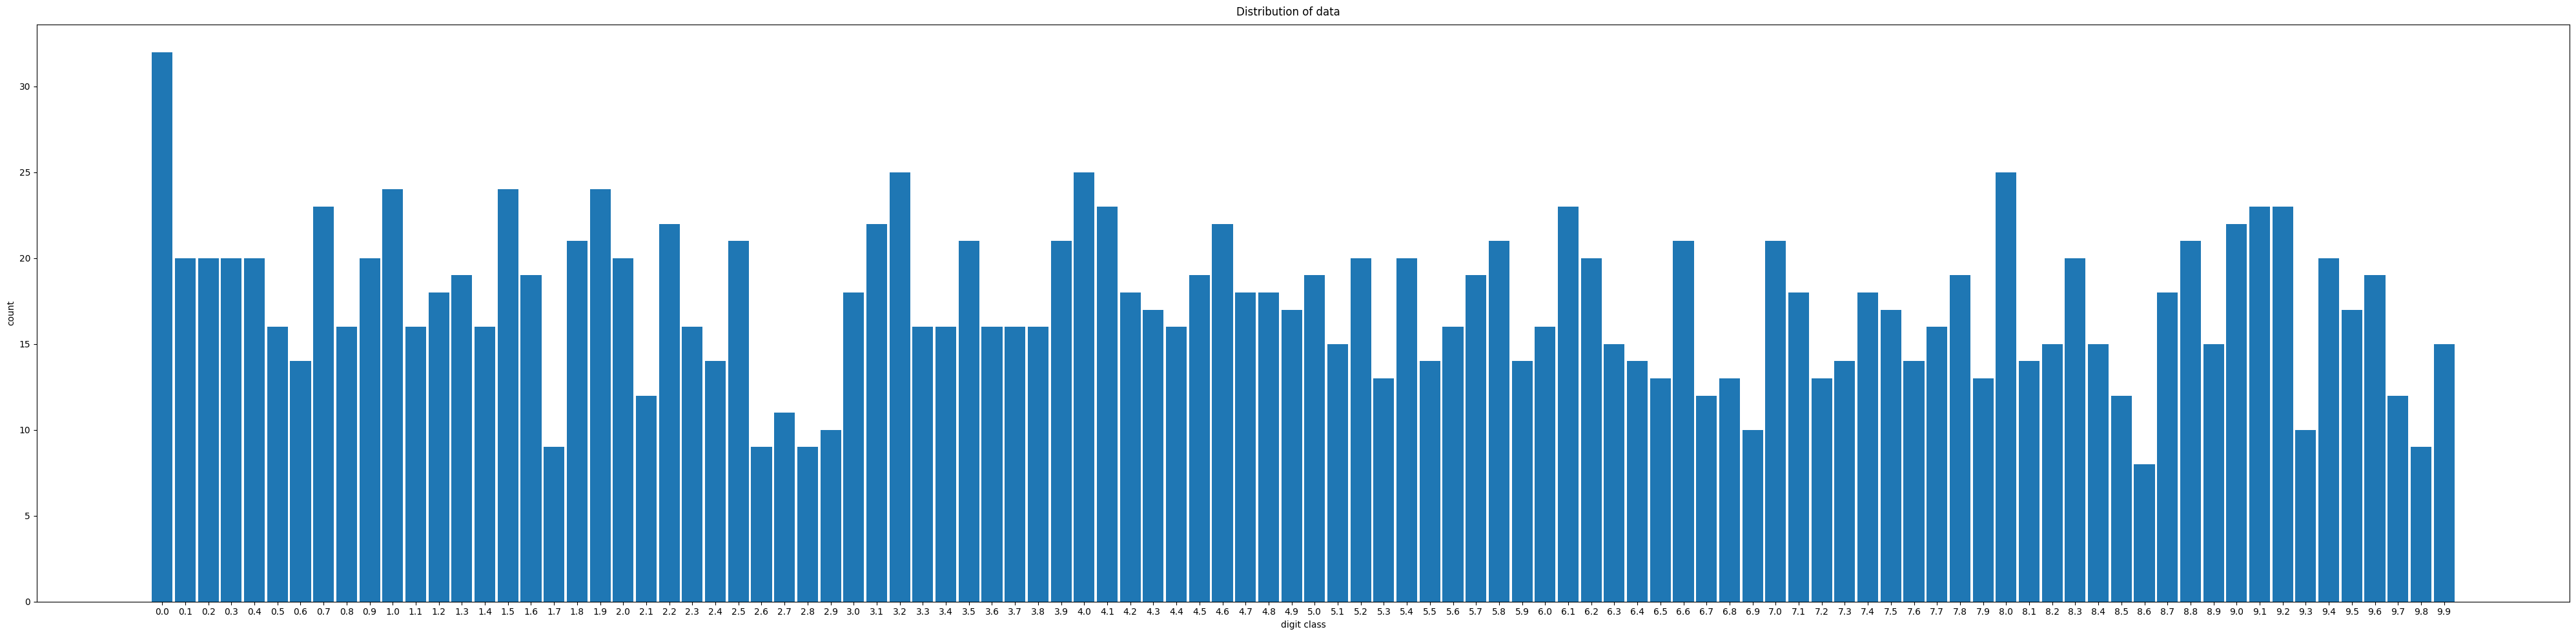

In [5]:
_, inverse = np.unique(y_data, return_inverse=True)
ziffer_bincount = np.bincount(inverse)
fig = plt.figure(figsize=(40, 10))
fig.suptitle("Distribution of data")
plt.bar(np.arange (0, 100/10, 0.1), ziffer_bincount, width=0.09, align='center')
plt.ylabel('count')
plt.xlabel('digit class')
plt.tight_layout()
_ = plt.xticks(np.arange(0, 100/10, 0.1))


### Define the model

The layout of the network ist a typcial CNN network with alternating 2x **Conv2D**, **BatchNormalization** and **MaxPool2D** layers. Finished after **flattening** with additional **Dense** layer.

**Dropout** between CNN layers are 0.2, between fully connected layers 0.4, but only the fully connected output layer.

* Shape of the input layer: (32, 32, 3)
* Shape of the output layer: (100) - classification 0.0 ... 9.9

In [6]:


inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.BatchNormalization()(inputs)
x = tf.keras.layers.Conv2D(64, (5, 5),  padding='same', activation="relu")(x)
x = tf.keras.layers.Conv2D(64, (1, 1),  padding='same', activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=(4,4))(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Conv2D(64, (3, 3),  padding='same', activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Conv2D(64, (3, 3),  padding='same', activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=(4,4))(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Conv2D(32,(3, 3),  padding='same', activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Conv2D(32, (3, 3),  padding='same', activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=(2,2))(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(100)(x)

model = tf.keras.Model(inputs=inputs, outputs=output)

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    metrics = ["accuracy"]
)
model.summary()


2025-05-04 06:40:22.895249: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 2, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             

 Total params: 114,928 (448.94 KB)

 Trainable params: 114,410 (446.91 KB)

 Non-trainable params: 518 (2.02 KB)

# Training
The input pictures are randomly scattered for brightness and pixel shift variations. These is implemented with a ImageDataGenerator.


The training is in one step. 

The best model will be stored as \<modelname\>_best.h5

### Augmentation

Augmentation uses shift, zoom, brightness, shear

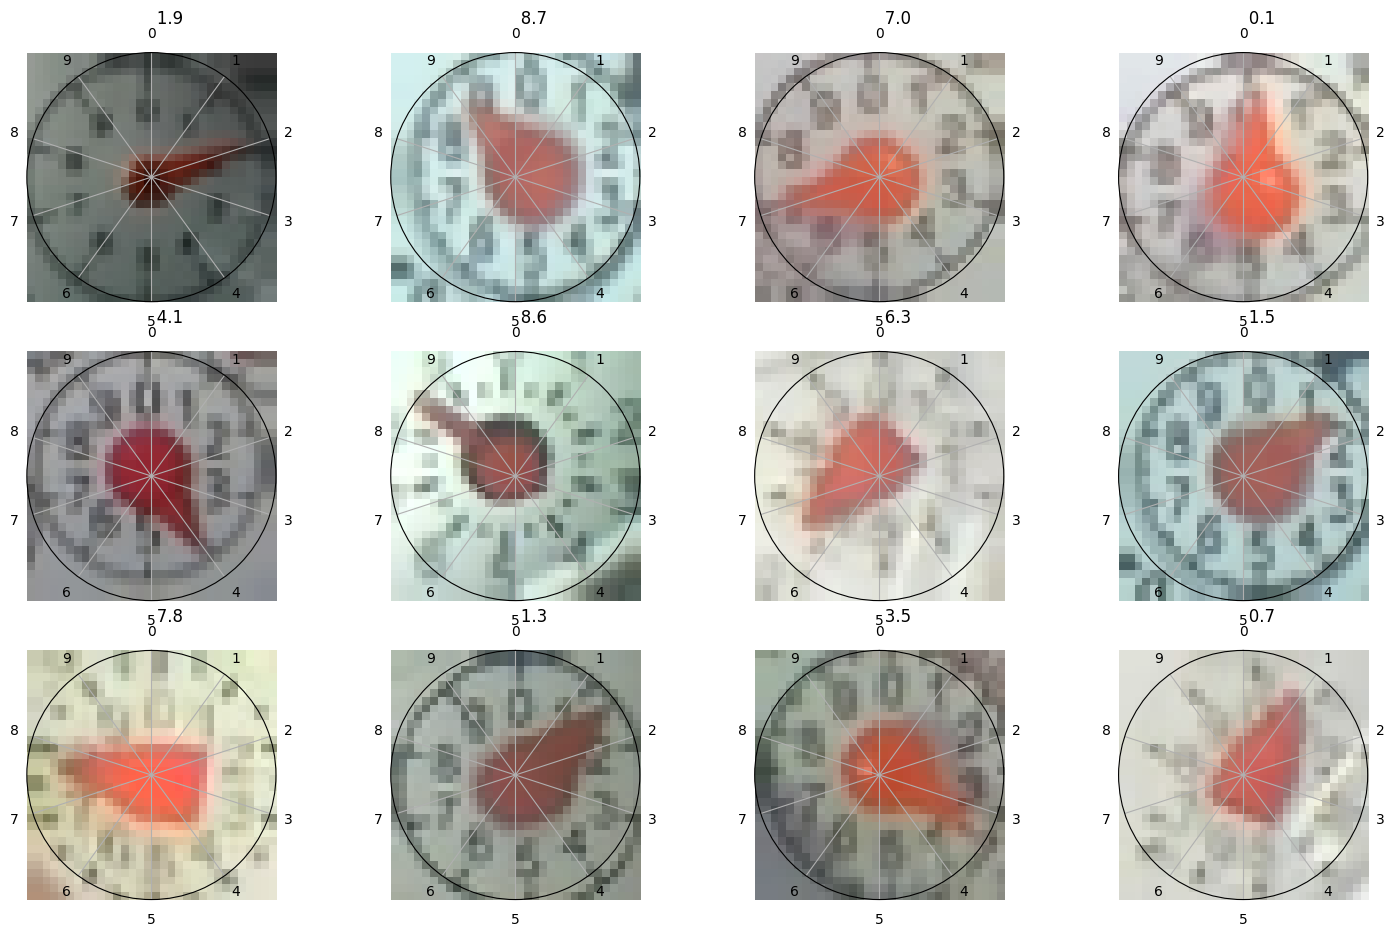

In [7]:
from numpy import pi
import random

Batch_Size = 8
Shift_Range = 1
Zoom_Range = 0.05
Brightness_Range = 0.2
ShearRange= 1
Rotation_Range=0

def add_noise(img):
    '''Add random noise to an image'''
    VARIABILITY = 3
    deviation = VARIABILITY*random.random()
    noise = np.random.normal(0, deviation, img.shape)
    img += noise
    np.clip(img, 0., 255.)
    return img

datagen = ImageDataGenerator(width_shift_range=[-Shift_Range,Shift_Range], 
                height_shift_range=[-Shift_Range,Shift_Range],
                brightness_range=[1-Brightness_Range,1+Brightness_Range],
                zoom_range=Zoom_Range,
                channel_shift_range=5,
                shear_range=ShearRange,
                rotation_range=Rotation_Range,
                #preprocessing_function=add_noise
                #rescale=1/255
                )
datagen_val = ImageDataGenerator()
train_iterator = datagen.flow(X_train, y_train, batch_size=Batch_Size)
validation_iterator = datagen_val.flow(X_test, y_test, batch_size=Batch_Size)


columns=4
rows=3

fig = plt.figure(figsize=(18, 11))
for i in range(1, columns*rows +1):
    img, label = next(train_iterator)
    ax0 = fig.add_subplot(rows, columns, i)
    target = (np.argmax(label[0])/10)
    plt.title("{:10.1f}\n".format(target))  # set title
    plt.imshow(img[0].astype(np.uint8))
    plt.axis('off')
    ax=plt.gca()
    ax.get_xaxis().set_visible(False) 
    ax2 = fig.add_subplot(rows, columns, i, polar=True, label="polar")
    ax2.set_facecolor("None")
    # suppress the radial labels
    plt.setp(ax.get_yticklabels(), visible=False)

    # set the circumference labels
    ax2.set_xticks(np.linspace(0, 2*pi, 10, endpoint=False))
    ax2.set_xticklabels(range(10))
    ax2.yaxis.grid(False)
    
    # make the labels go clockwise
    ax2.set_theta_direction(-1)
    # place 0 at the top
    ax2.set_theta_offset(pi/2.0)    
    ax2.set_yticklabels([])


    # plt.grid('off')

    # put the points on the circumference
    plt.ylim(0,1)
plt.show()


In [8]:
from keras.callbacks import EarlyStopping, LearningRateScheduler, ModelCheckpoint, ReduceLROnPlateau

Epoch_Anz = 400

earlystop = EarlyStopping(monitor='val_loss', mode='min' , patience=30, verbose=0,  restore_best_weights=True)
#mc = ModelCheckpoint(TFliteNamingAndVersion + '_best.h5', monitor='val_loss', mode='min', verbose=0, save_best_only=True, initial_value_threshold=.9)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=5, min_lr=1e-5, verbose=0)
history = model.fit(train_iterator, 
            validation_data=validation_iterator, 
            batch_size=Batch_Size, 
            epochs = Epoch_Anz,
            callbacks=[earlystop, reduce_lr],
            verbose=0)


/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


### Result
 
* Visualization of the training and validation results
* Validation should not much over train validation, because of the augmentation of train data (validation data not)
* Beware, the best model will be used. This can be from an earlier epoch as the last. (mostly the last -30)


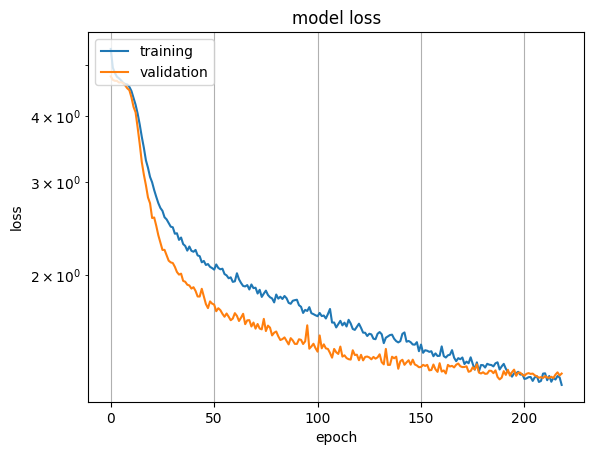

In [9]:
plt.semilogy(history.history['loss'])

if (Validation_Percentage > 0):
    plt.semilogy(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training','validation'], loc='upper left')
plt.grid(True)
plt.show()

### Model verification

* The following code uses the trained model to check the deviation for each picture (train + validation).
* The max_delta can be used to get the accuracy with allowed differences (for instance +/- 0.1)
* The first (max) 49 false predicted images will be shown
* A csv-file with all false predicted images will be created. It can be used for relabeling. Usage `python3 -m collectmeteranalog  --labelfile=ana-class100_s1_false_predicted.csv --model=ana-class100_s1q.tflite` (see https://github.com/haverland/collectmeteranalog)


 1/55 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step

 7/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 

13/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

19/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

25/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

...

48/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Tested images: 1739. 45 false predicted. Accuracy is: 0.9741230592294422


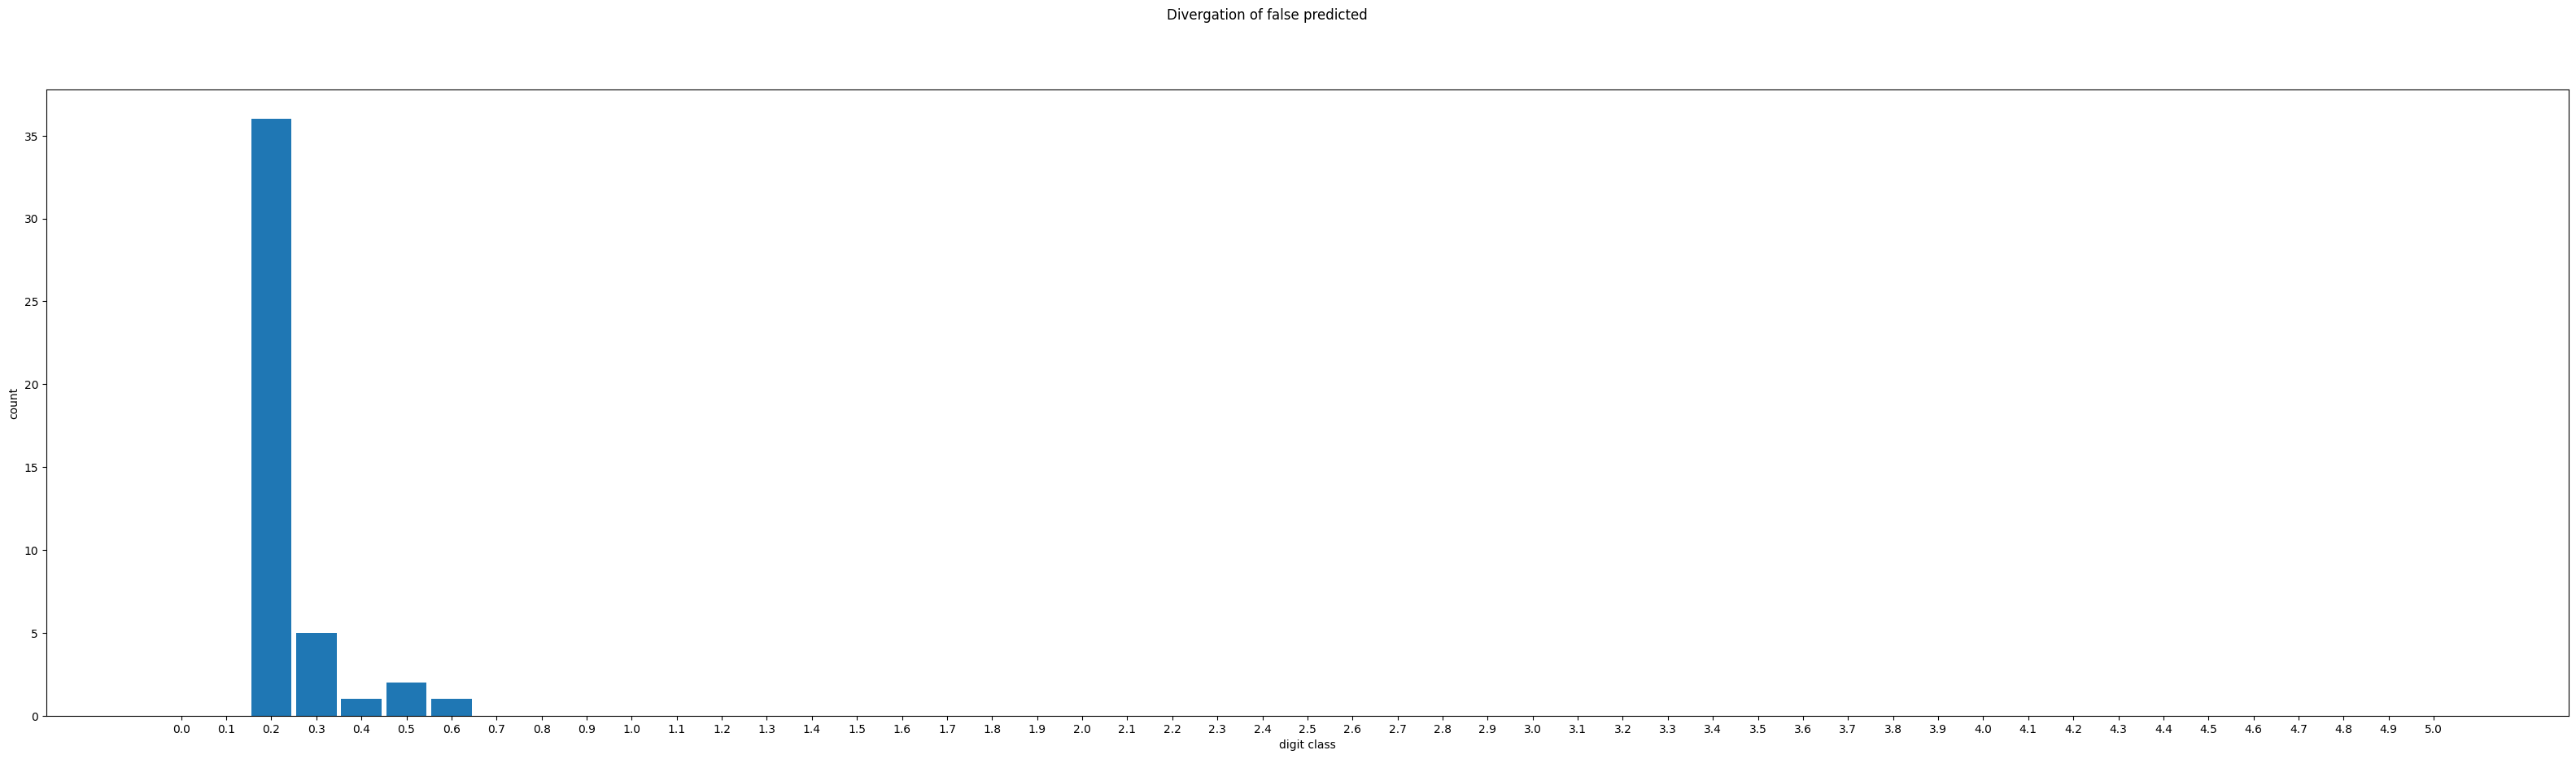

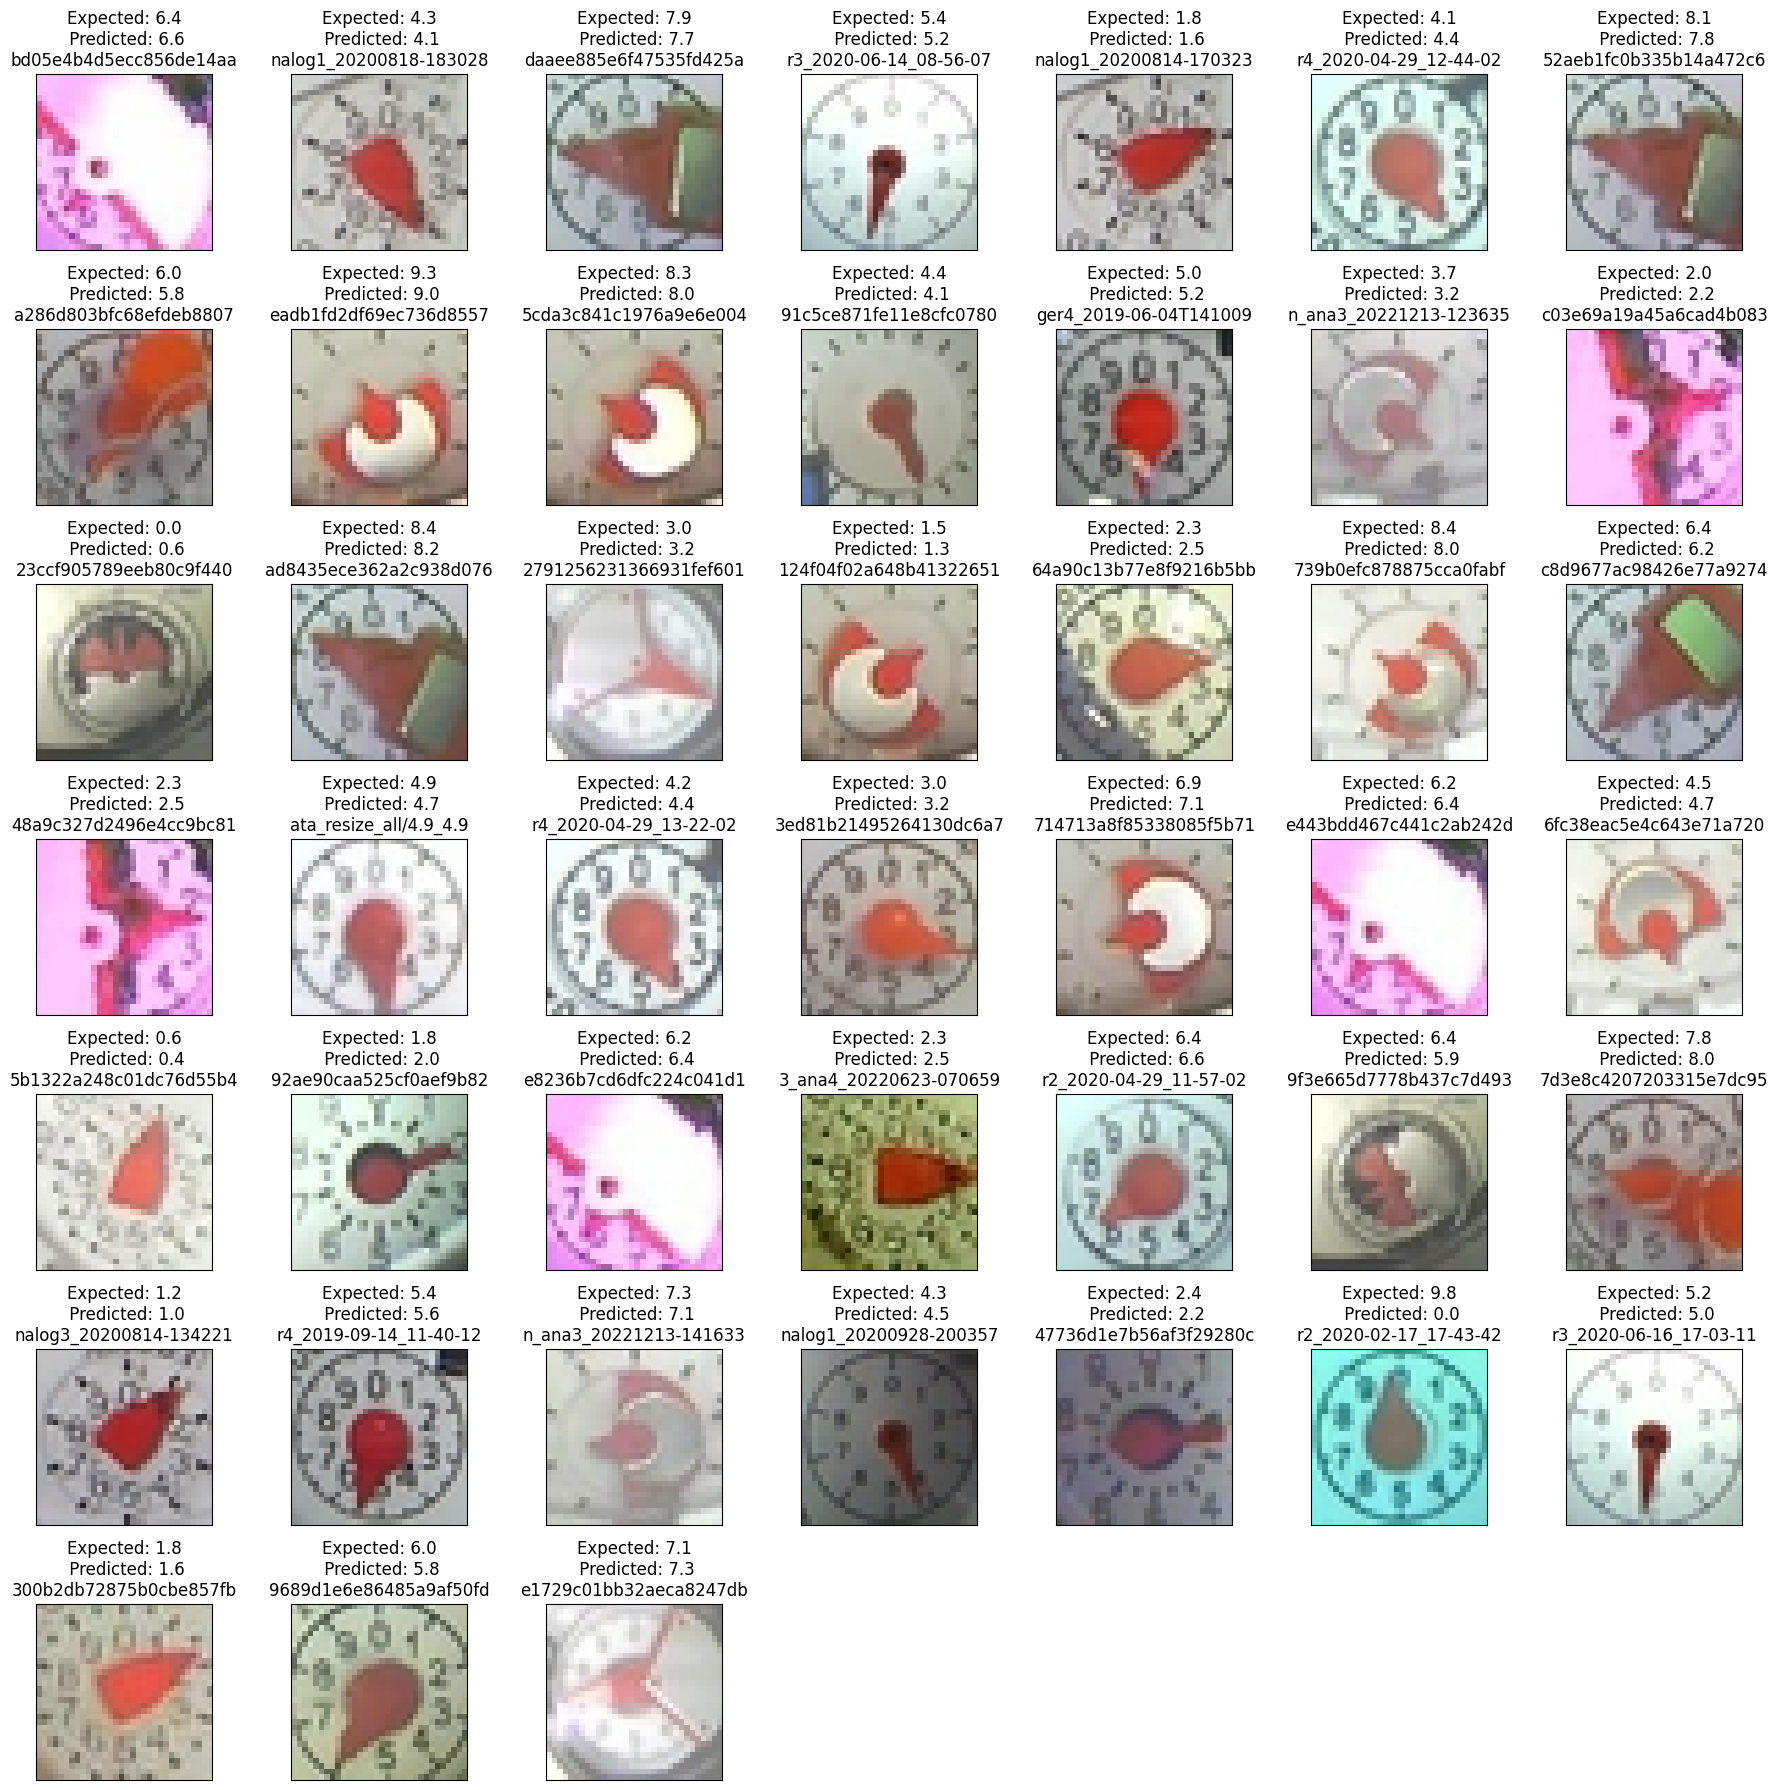

In [10]:
import numpy as np
from tensorflow import keras
import pandas as pd

max_delta=0.11

def plot_dataset(images, labels, columns=10, rows=5, figsize=(18, 10)):

    fig = plt.figure(figsize=figsize)
    
    for i in range(1, columns*rows +1):
        if (i>len(labels)):
            break
        fig.add_subplot(rows, columns, i)
        plt.title(labels[i-1])  # set title
        plt.imshow((images[i-1]).astype(np.uint8), aspect='1', extent=[0, 1, 0, 1])
        # yellow lines
        ax=plt.gca()
        ax.get_yaxis().set_visible(False) 
        ax.get_xaxis().set_visible(False) 
        
        plt.tight_layout()
    plt.show()

def plot_divergence(divergationset, title1, nb_classes):
    fig = plt.figure(figsize=(40, 10))
    fig.suptitle(title1)
    plt.bar(np.arange (0, nb_classes/10, 0.1), divergationset, width=0.09, align='center')
    plt.ylabel('count')
    plt.xlabel('digit class')
    plt.xticks(np.arange(0, nb_classes/10, 0.1))
    return fig

#model = keras.models.load_model(TFliteNamingAndVersion + "_best.h5")

classes = model.predict(x_data.astype(np.float32))
predictions = np.argmax(classes, axis=1).reshape(-1)/10

# 9.9 <> 0 = 0.1 and 1.1 <> 1.2 = 0.1
differences = np.minimum(np.abs(predictions-y_data), np.abs(predictions-(10-y_data)))
# used for filtering
false_differences = differences>max_delta
# only differences bigger than delta. so small differences can be ignored in early stages
false_predicted = differences[false_differences]
false_images = x_data[false_differences]
false_labels = [ "Expected: " + str(y1) + "\n Predicted: " + str(p) + "\n" + str(f)[-26:-4] for y1, p, f in zip(y_data[false_differences], predictions[false_differences], f_data[false_differences])]
false_files = [ f for f in  f_data[false_differences]]

print(f"Tested images: {len(y_data)}. {len(false_predicted)} false predicted. Accuracy is: {1-len(false_predicted)/len(y_data)}")
# plot the differences (max difference can only be 5.0)
plot_divergence(np.bincount(np.array(np.round(false_predicted*10)).astype(int), minlength=51), "Divergation of false predicted", 51)

# plot the false predicted images
plot_dataset(np.array(false_images), false_labels, columns=7, rows=7, figsize=(18,18))
#print(false_files)
fpf = pd.DataFrame(false_files)

# the csv can be used with collectmeterdigits to fix labels
# python3 -m collectmeteranalog  --labelfile=ana-class10_0168_s1_false_predicted.csv --model=ana-class100_0168_s1_q.tflite
fpf.to_csv(f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}" + '_false_predicted.csv')


### Save the model

* Save the model to the file with the "tflite" file format
* quantize the model and store it as -q.tflite

In [11]:
#FileName = TFliteNamingAndVersion
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}.tflite"

# TensorFlow Lite conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open(FileName, "wb") as f:
    f.write(tflite_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpsoux5qh3/assets


INFO:tensorflow:Assets written to: /tmp/tmpsoux5qh3/assets


Saved artifact at '/tmp/tmpsoux5qh3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  140364623522384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623522000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623522576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623523152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623520464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623523536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14036462352334

Model saved successfully. File: models_tmp/ana-class100_3_s1.tflite
File size: 466076 bytes


W0000 00:00:1746341413.260664    2074 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746341413.260690    2074 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 06:50:13.260952: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsoux5qh3
2025-05-04 06:50:13.262121: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 06:50:13.262133: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpsoux5qh3
I0000 00:00:1746341413.275781    2074 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-05-04 06:50:13.278158: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 06:50:13.358729: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpsoux5qh3
2025-05-04 06:50:13.381985: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

In [12]:
#FileName = TFliteNamingAndVersion + "_q" + ".tflite"
FileName = f"{Output_Dir}/{TFlite_MainType}_{TFlite_Version}_{TFlite_Size}_q.tflite"

# Representative dataset function
def representative_dataset():
    for n in range(x_data[0].shape[0]):
        data = np.expand_dims(x_data[n], axis=0)
        yield [data.astype(np.float32)]

# TensorFlow Lite conversion with optimizations
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
tflite_quant_model = converter.convert()

# Save the converted model to the specified file
with open(FileName, "wb") as f:
    f.write(tflite_quant_model)

print(f"Model saved successfully. File: {FileName}")
print(f"File size: {Path(FileName).stat().st_size} bytes")

INFO:tensorflow:Assets written to: /tmp/tmprtdotw82/assets


INFO:tensorflow:Assets written to: /tmp/tmprtdotw82/assets


Saved artifact at '/tmp/tmprtdotw82'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  140364623522384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623522000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623520848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623522576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623523152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623520464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623521616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140364623523536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14036462352334

/home/runner/work/neural-network-analog-needle-readout/neural-network-analog-needle-readout/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model saved successfully. File: models_tmp/ana-class100_3_s1_q.tflite
File size: 133504 bytes


W0000 00:00:1746341414.338056    2074 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746341414.338074    2074 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 06:50:14.338230: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprtdotw82
2025-05-04 06:50:14.339843: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 06:50:14.339871: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmprtdotw82
2025-05-04 06:50:14.357075: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 06:50:14.444373: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmprtdotw82
2025-05-04 06:50:14.466883: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 128656 microseconds.
fully_quantize: 0, inference_type: 6, input_